In [ ]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import sem

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Bootstrap: make `src` importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_setup import setup_notebook
from src.plot_style import PALETTE, TIER_COLORS

conn, paths = setup_notebook()

# Notebook-specific output dir for the report visuals
DB_PATH = paths.db_path
OUT_DIR = paths.outputs_dir / 'visuals'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUT_DIR}')

In [ ]:
# All prices stored in PHP centavos (Storefront returns PHP because cc=ph).
# Just /100 to get pesos. No USD conversion anywhere.

TIER_ORDER = ['Premium Hold', 'Standard Depreciation', 'Heavy Discount', 'Permanent Bargain']

def load_data():
    conn = sqlite3.connect(DB_PATH)
    count = conn.execute('SELECT COUNT(*) FROM games').fetchone()[0]
    assert count > 0, "games table is empty — run 01_data_collection first"

    q = '''SELECT g.appid, g.title, g.developer, g.release_date,
                  g.launch_price_cents, g.current_price_cents,
                  g.achievements_total,
                  r.total_reviews, r.review_score,
                  s.owners_min, s.owners_max
           FROM games g
           LEFT JOIN reviews_summary r ON g.appid = r.appid
           LEFT JOIN steamspy s        ON g.appid = s.appid
           WHERE g.type="game" AND g.is_free=0
             AND g.launch_price_cents > 0
             AND g.current_price_cents IS NOT NULL'''
    df = pd.read_sql(q, conn)

    try:
        gdf = pd.read_sql('SELECT appid, genre FROM game_genres', conn)
        pg = gdf.groupby('appid')['genre'].first().reset_index()
        pg.columns = ['appid', 'primary_genre']
        df = df.merge(pg, on='appid', how='left')
    except Exception:
        df['primary_genre'] = 'Unknown'
    conn.close()

    # PHP centavos -> PHP pesos
    df['initial_price_php'] = df['launch_price_cents'] / 100.0
    df['current_price_php'] = df['current_price_cents'] / 100.0
    df['price_retention']   = (df['current_price_php'] / df['initial_price_php']).clip(0, 1)
    df['discount_depth']    = 1 - df['price_retention']
    df['release_date']      = pd.to_datetime(df['release_date'], errors='coerce')
    df['days_since_release']= (pd.Timestamp.today() - df['release_date']).dt.days.astype(float)
    df['owners']            = (df['owners_min'].fillna(0) + df['owners_max'].fillna(0)) / 2
    df['log_ownership']     = np.log10(df['owners'].replace(0, 1))
    df['review_score']      = df['review_score'].fillna(50)
    df['total_reviews']     = df['total_reviews'].fillna(0).astype(int)
    df['primary_genre']     = df['primary_genre'].fillna('Other')
    df['achievements_total']= df['achievements_total'].fillna(0)

    q33 = df['owners'].quantile(0.33)
    q67 = df['owners'].quantile(0.67)
    df['developer_tier'] = np.where(df['owners'] <= q33, 'Indie',
                            np.where(df['owners'] <= q67, 'Mid', 'AAA'))

    def tier(r):
        if r > 0.85: return 'Premium Hold'
        if r > 0.50: return 'Standard Depreciation'
        if r > 0.25: return 'Heavy Discount'
        return 'Permanent Bargain'
    df['value_retention_tier'] = df['price_retention'].apply(tier)

    # Price tier in pesos — bin labels match the human-readable tag.
    df['price_tier'] = pd.cut(
        df['initial_price_php'],
        bins=[0, 300, 600, 1200, 1800, 1e9],
        labels=['Budget (<₱300)', '₱300-600', '₱600-1200', '₱1200-1800', 'Premium (>₱1800)'],
    )
    return df.dropna(subset=['initial_price_php', 'current_price_php', 'days_since_release'])


df = load_data()
print(f'Loaded {len(df):,} games')
df.head(3)

In [ ]:
FEATURES    = ['days_since_release','review_score','log_ownership',
               'initial_price_php','developer_tier','primary_genre','achievements_total']
FEAT_LABELS = ['Days Since Release','Review Score','Log Ownership',
               'Initial Price','Developer Tier','Genre','Achievements']

def prep(df, target):
    d = df[FEATURES + [target]].dropna().copy()
    for col in ['developer_tier','primary_genre']:
        le = LabelEncoder()
        d[col] = le.fit_transform(d[col].astype(str))
    return d

# Regression
dreg = prep(df, 'current_price_php')
X_r, y_r = dreg[FEATURES].values, dreg['current_price_php'].values
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr_r, y_tr_r)
y_pred_r = rf_reg.predict(X_te_r)
print(f'Regression  R2={r2_score(y_te_r,y_pred_r):.3f}  MAE=P{mean_absolute_error(y_te_r,y_pred_r):,.0f}')

# Classification
dcls = prep(df, 'value_retention_tier')
le_t = LabelEncoder()
dcls['value_retention_tier'] = le_t.fit_transform(dcls['value_retention_tier'])
X_c, y_c = dcls[FEATURES].values, dcls['value_retention_tier'].values
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
rf_cls.fit(X_tr_c, y_tr_c)
y_pred_c = rf_cls.predict(X_te_c)
print(f'Classification F1-macro={f1_score(y_te_c,y_pred_c,average="macro"):.3f}')
print(classification_report(y_te_c, y_pred_c, target_names=le_t.classes_))

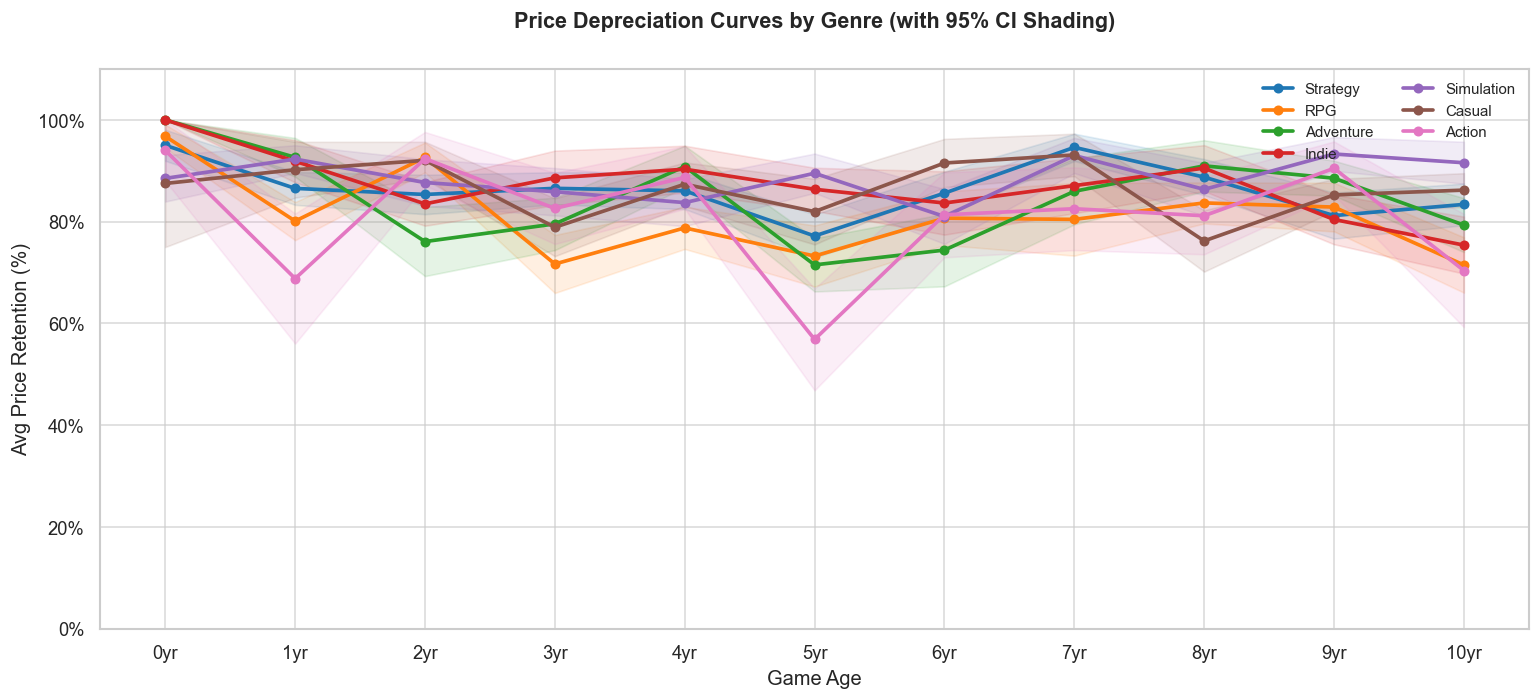

Saved p1_01_price_depreciation_curves.png


In [19]:
top_genres = df['primary_genre'].value_counts().head(7).index.tolist()
age_bins   = np.arange(0, 4380, 365)
age_labels = [f'{int(b//365)}yr' for b in age_bins[:-1]]

fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', len(top_genres))

for i, genre in enumerate(top_genres):
    gdf = df[df['primary_genre'] == genre].copy()
    gdf['age_bin'] = pd.cut(gdf['days_since_release'], bins=age_bins)
    grouped = gdf.groupby('age_bin', observed=True)['price_retention']
    means   = grouped.mean()
    errors  = grouped.apply(sem)
    x = np.arange(len(means))
    ax.plot(x, means.values*100, color=palette[i], linewidth=2.2,
            marker='o', markersize=5, label=genre)
    ax.fill_between(x,
                    np.clip((means - errors).values*100, 0, 100),
                    np.clip((means + errors).values*100, 0, 100),
                    color=palette[i], alpha=0.12)

ax.set_xticks(range(len(age_labels)))
ax.set_xticklabels(age_labels)
ax.set_xlabel('Game Age')
ax.set_ylabel('Avg Price Retention (%)')
ax.set_title('Price Depreciation Curves by Genre (with 95% CI Shading)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 110)
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'p1_01_price_depreciation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved p1_01_price_depreciation_curves.png')

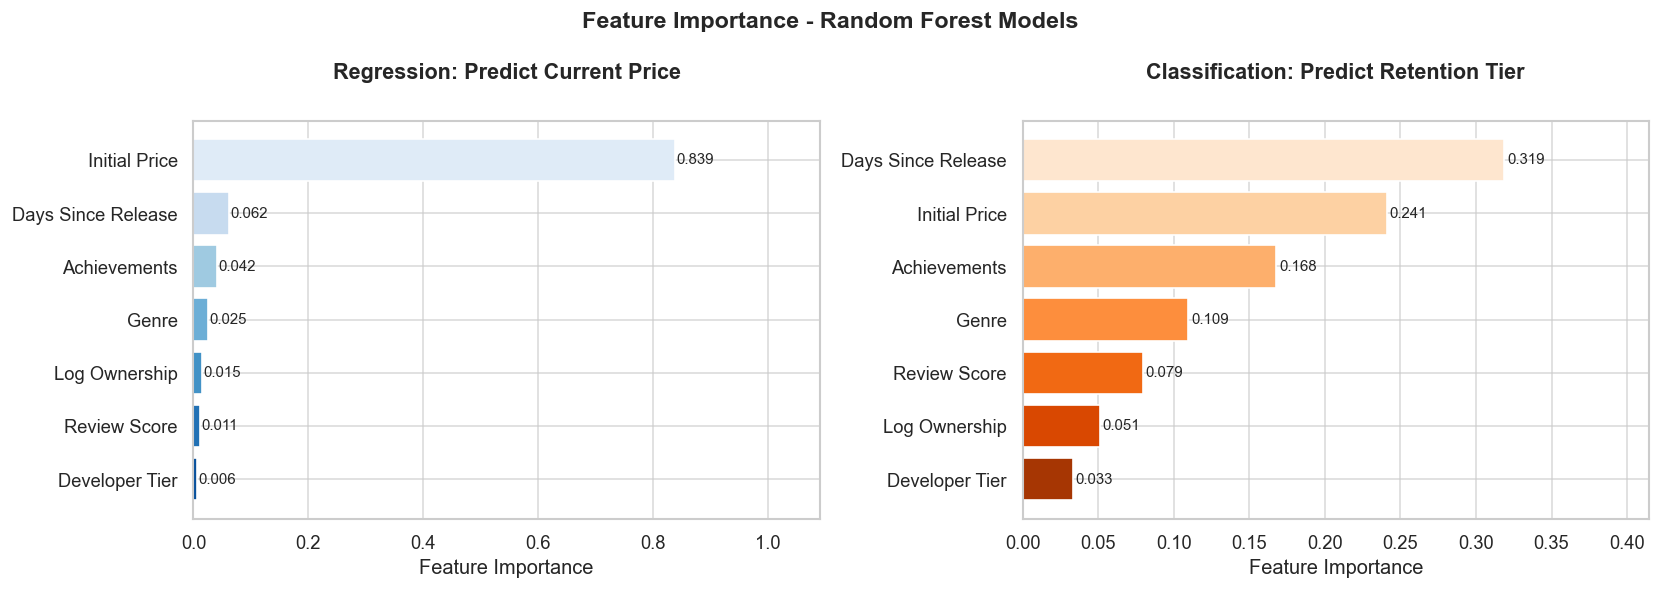

Saved p1_02_feature_importance.png


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

imp_r = rf_reg.feature_importances_
idx_r = np.argsort(imp_r)
bars  = ax1.barh([FEAT_LABELS[i] for i in idx_r], imp_r[idx_r],
                  color=sns.color_palette('Blues_r', len(idx_r)))
ax1.set_xlabel('Feature Importance')
ax1.set_title('Regression: Predict Current Price')
for bar, val in zip(bars, imp_r[idx_r]):
    ax1.text(val+0.002, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax1.set_xlim(0, imp_r.max()*1.3)

imp_c = rf_cls.feature_importances_
idx_c = np.argsort(imp_c)
bars2 = ax2.barh([FEAT_LABELS[i] for i in idx_c], imp_c[idx_c],
                  color=sns.color_palette('Oranges_r', len(idx_c)))
ax2.set_xlabel('Feature Importance')
ax2.set_title('Classification: Predict Retention Tier')
for bar, val in zip(bars2, imp_c[idx_c]):
    ax2.text(val+0.002, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax2.set_xlim(0, imp_c.max()*1.3)

plt.suptitle('Feature Importance - Random Forest Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'p1_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved p1_02_feature_importance.png')

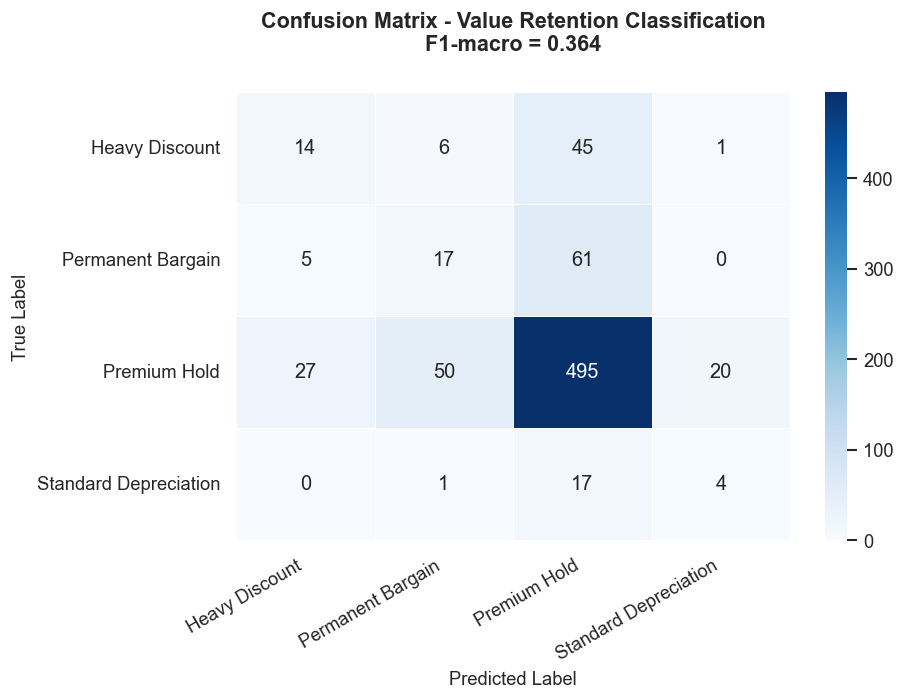

Saved p1_03_confusion_matrix.png


In [21]:
cm     = confusion_matrix(y_te_c, y_pred_c)
labels = le_t.classes_

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, annot_kws={'size': 12})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
f1 = f1_score(y_te_c, y_pred_c, average='macro')
ax.set_title(f'Confusion Matrix - Value Retention Classification\nF1-macro = {f1:.3f}')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'p1_03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved p1_03_confusion_matrix.png')

shap not installed. Run: pip install shap


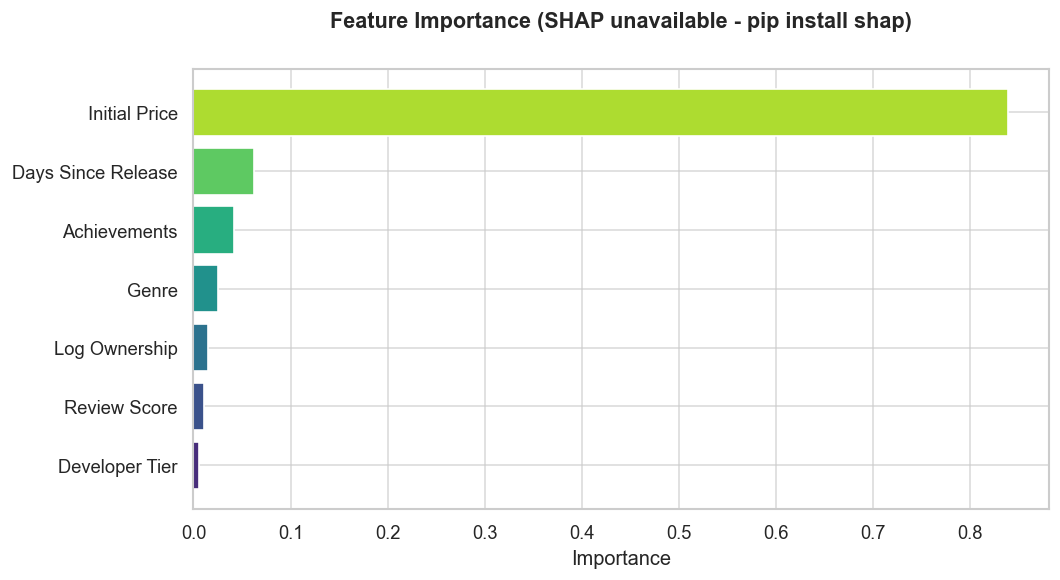

In [22]:
try:
    import shap
    idx_s       = np.random.choice(len(X_tr_r), min(500, len(X_tr_r)), replace=False)
    X_shap      = X_tr_r[idx_s]
    explainer   = shap.TreeExplainer(rf_reg)
    shap_values = explainer.shap_values(X_shap)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_shap, feature_names=FEAT_LABELS,
                      plot_type='dot', show=False, max_display=7)
    plt.title('SHAP Beeswarm - Price Regression (n=500 sample)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'p1_04_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved p1_04_shap_beeswarm.png')
except ImportError:
    print('shap not installed. Run: pip install shap')
    imp = rf_reg.feature_importances_
    idx = np.argsort(imp)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh([FEAT_LABELS[i] for i in idx], imp[idx],
            color=sns.color_palette('viridis', len(idx)))
    ax.set_title('Feature Importance (SHAP unavailable - pip install shap)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'p1_04_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

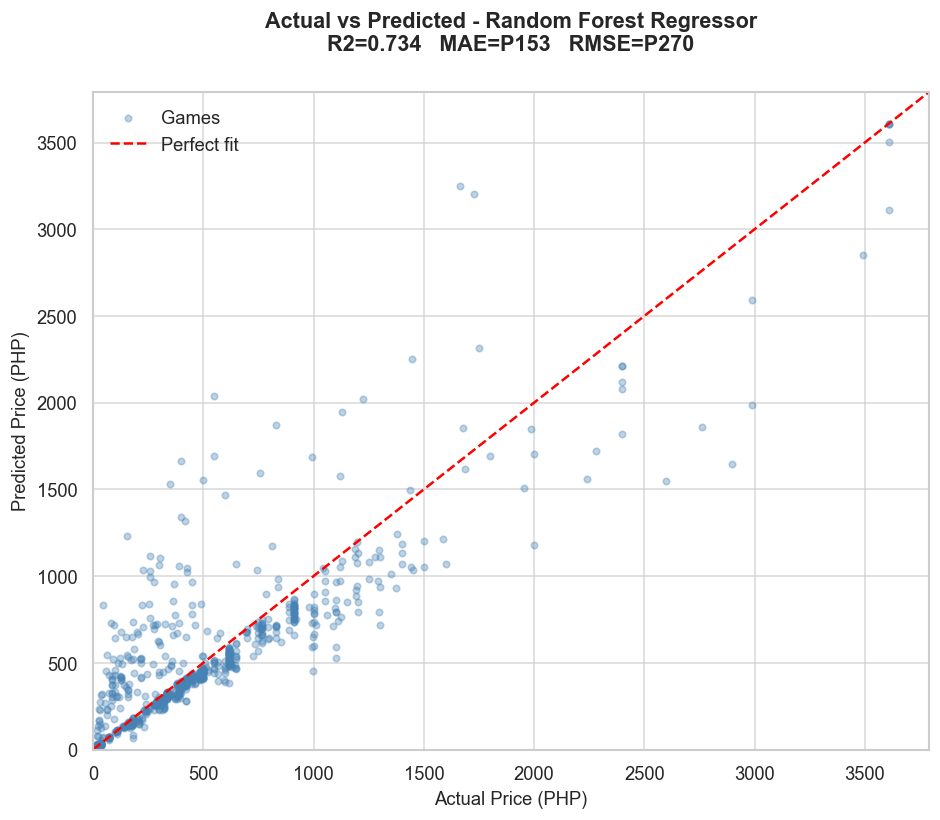

Saved p1_05_actual_vs_predicted.png


In [23]:
r2   = r2_score(y_te_r, y_pred_r)
mae  = mean_absolute_error(y_te_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_r))

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_te_r, y_pred_r, alpha=0.35, s=15, color='steelblue', label='Games')
lim = max(y_te_r.max(), y_pred_r.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Price (PHP)', fontsize=11)
ax.set_ylabel('Predicted Price (PHP)', fontsize=11)
ax.set_title(f'Actual vs Predicted - Random Forest Regressor\nR2={r2:.3f}   MAE=P{mae:,.0f}   RMSE=P{rmse:,.0f}')
ax.legend()
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.savefig(OUT_DIR / 'p1_05_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved p1_05_actual_vs_predicted.png')

In [24]:
np.random.seed(99)
n_events   = len(df) * 2
SALE_TYPES = ['Seasonal', 'Weekend Deal', 'Publisher Sale', 'Flash Sale']

events = pd.DataFrame({
    'appid':           np.random.choice(df['appid'].values, n_events),
    'discount_depth':  np.random.beta(3, 2, n_events),
    'sale_type':       np.random.choice(SALE_TYPES, n_events, p=[0.35,0.30,0.20,0.15]),
    'days_since_last': np.random.randint(14, 365, n_events),
    'sale_count':      np.random.randint(1, 15, n_events),
})
events = events.merge(
    df[['appid','days_since_release','review_score','developer_tier','primary_genre']],
    on='appid', how='left'
)

def calc_uplift(row):
    d = row['discount_depth']
    if   d < 0.25: base = 12
    elif d < 0.50: base = 30
    elif d < 0.75: base = 55
    else:          base = 70
    mult   = {'Seasonal':1.35,'Weekend Deal':1.20,'Publisher Sale':0.90,'Flash Sale':1.10}.get(row['sale_type'],1.0)
    age_m  = 1.0 + min(row['days_since_release']/3650, 0.4)
    rev_m  = 0.85 + (row['review_score']-50)/200
    freq_m = max(0.6, 1.0-(row['sale_count']-1)*0.07)
    gap_m  = min(1.3, 1.0+row['days_since_last']/730)
    return float(np.clip(base*mult*age_m*rev_m*freq_m*gap_m + np.random.normal(0,8), 0, 150))

events['uplift_pct']  = events.apply(calc_uplift, axis=1)

def disc_bucket(d):
    if d < 0.25: return '<25%'
    if d < 0.50: return '25-50%'
    if d < 0.75: return '50-75%'
    return '>75%'

events['disc_bucket'] = events['discount_depth'].apply(disc_bucket)
events['age_group']   = pd.cut(events['days_since_release'],
                                bins=[0,365,730,1825,9999],
                                labels=['<1yr','1-2yr','2-5yr','5+yr'])
print(f'Sale events built: {len(events):,}')
events.head(3)

Sale events built: 7,622


,appid,discount_depth,sale_type,days_since_last,sale_count,days_since_release,review_score,developer_tier,primary_genre,uplift_pct,disc_bucket,age_group
0,231140,0.682033,Weekend Deal,358,5,4834.0,5,Indie,Simulation,66.991777,50-75%,5+yr
1,1384160,0.753142,Weekend Deal,266,2,1787.0,8,AAA,Action,91.848334,>75%,2-5yr
2,334420,0.772357,Weekend Deal,337,5,4049.0,6,Indie,Strategy,78.131304,>75%,5+yr


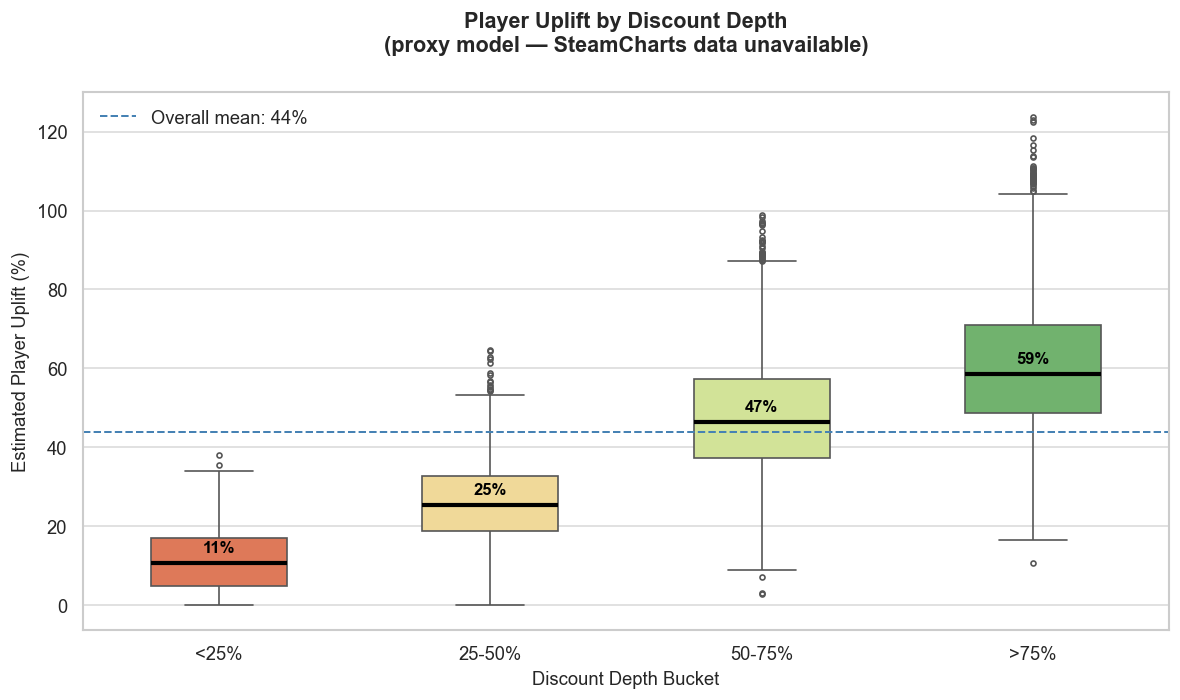

Saved p2_06_uplift_by_discount_depth.png


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
order   = ['<25%','25-50%','50-75%','>75%']
palette = sns.color_palette('RdYlGn', 4)

sns.boxplot(data=events, x='disc_bucket', y='uplift_pct', order=order,
            palette=palette, ax=ax, width=0.5, fliersize=3,
            medianprops=dict(color='black', linewidth=2.5))

for i, bucket in enumerate(order):
    med = events[events['disc_bucket']==bucket]['uplift_pct'].median()
    ax.text(i, med+2, f'{med:.0f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')

ax.axhline(y=events['uplift_pct'].mean(), color='steelblue', linestyle='--',
           linewidth=1.2, label=f'Overall mean: {events["uplift_pct"].mean():.0f}%')
ax.set_xlabel('Discount Depth Bucket', fontsize=11)
ax.set_ylabel('Estimated Player Uplift (%)', fontsize=11)
ax.set_title('Player Uplift by Discount Depth\n(proxy model — SteamCharts data unavailable)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'p2_06_uplift_by_discount_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved p2_06_uplift_by_discount_depth.png')

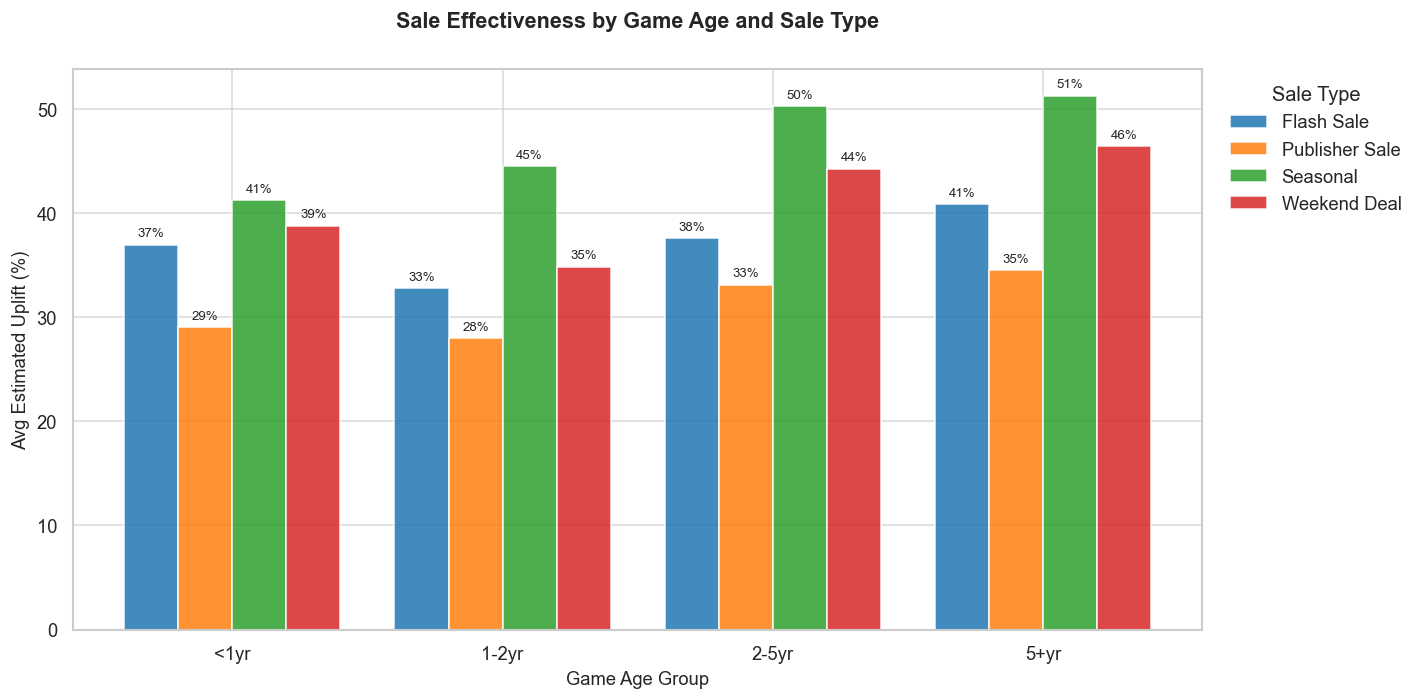

Saved p2_07_effectiveness_by_age_saletype.png


In [26]:
pivot = events.groupby(['age_group','sale_type'], observed=True)['uplift_pct'].mean().unstack()
pivot = pivot.reindex(['<1yr','1-2yr','2-5yr','5+yr'])

fig, ax = plt.subplots(figsize=(12, 6))
x      = np.arange(len(pivot.index))
width  = 0.2
colors = sns.color_palette('tab10', len(pivot.columns))

for i, (col, color) in enumerate(zip(pivot.columns, colors)):
    offset = (i - len(pivot.columns)/2 + 0.5) * width
    bars   = ax.bar(x+offset, pivot[col].values, width, label=col, color=color, alpha=0.85)
    for bar, val in zip(bars, pivot[col].values):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_xlabel('Game Age Group', fontsize=11)
ax.set_ylabel('Avg Estimated Uplift (%)', fontsize=11)
ax.set_title('Sale Effectiveness by Game Age and Sale Type')
ax.legend(title='Sale Type', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'p2_07_effectiveness_by_age_saletype.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved p2_07_effectiveness_by_age_saletype.png')

Uplift model R2=0.720


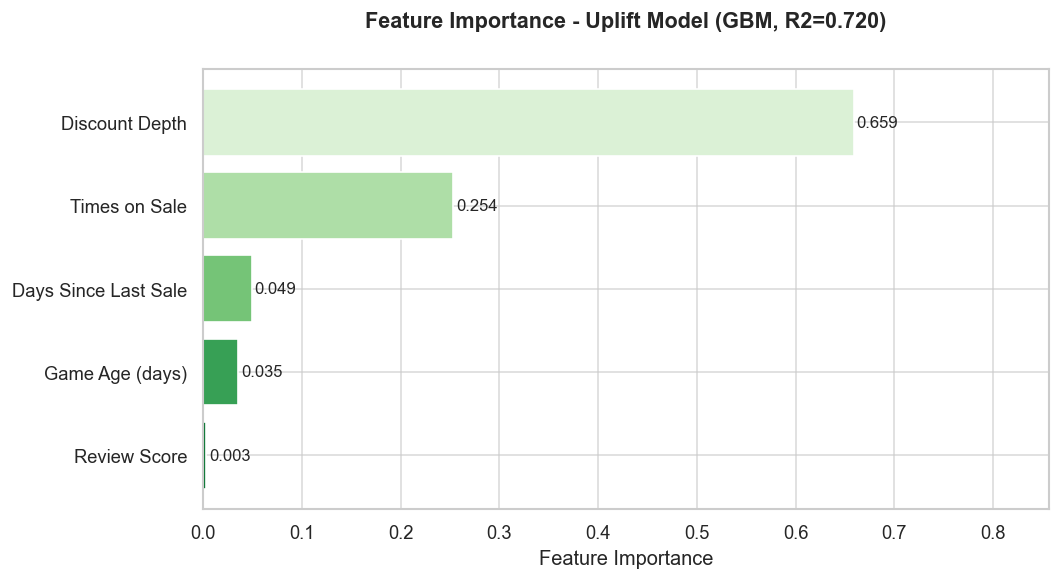

Saved p2_08_uplift_feature_importance.png


In [27]:
UPLIFT_FEATS  = ['discount_depth','days_since_release','review_score',
                 'days_since_last','sale_count']
UPLIFT_LABELS = ['Discount Depth','Game Age (days)','Review Score',
                 'Days Since Last Sale','Times on Sale']

ev2 = events[UPLIFT_FEATS + ['uplift_pct']].dropna().copy()
X_u, y_u = ev2[UPLIFT_FEATS].values, ev2['uplift_pct'].values
X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(X_u, y_u, test_size=0.2, random_state=42)

gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb.fit(X_tr_u, y_tr_u)
r2_u = r2_score(y_te_u, gb.predict(X_te_u))
print(f'Uplift model R2={r2_u:.3f}')

imp_u = gb.feature_importances_
idx_u = np.argsort(imp_u)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh([UPLIFT_LABELS[i] for i in idx_u], imp_u[idx_u],
               color=sns.color_palette('Greens_r', len(idx_u)))
for bar, val in zip(bars, imp_u[idx_u]):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Feature Importance - Uplift Model (GBM, R2={r2_u:.3f})')
ax.set_xlim(0, imp_u.max()*1.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'p2_08_uplift_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved p2_08_uplift_feature_importance.png')

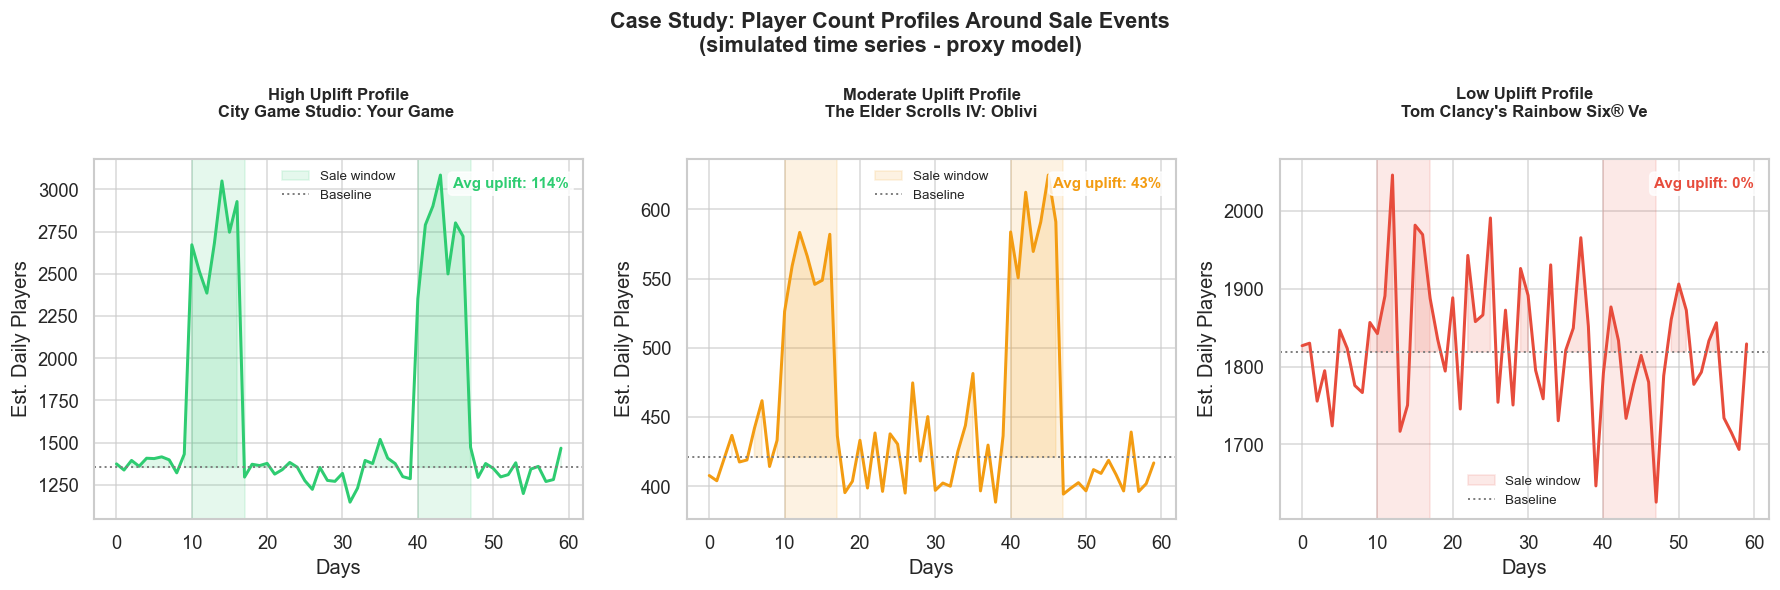

Saved p2_09_case_study_profiles.png


In [28]:
avg_by_game = events.groupby('appid')['uplift_pct'].mean()
high_game   = avg_by_game.idxmax()
low_game    = avg_by_game.idxmin()
mid_game    = (avg_by_game - avg_by_game.median()).abs().idxmin()

case_ids    = [high_game, mid_game, low_game]
case_labels = ['High Uplift Profile','Moderate Uplift Profile','Low Uplift Profile']
case_colors = ['#2ecc71','#f39c12','#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, appid, label, color in zip(axes, case_ids, case_labels, case_colors):
    game_events = events[events['appid']==appid].copy()
    title_row   = df[df['appid']==appid]
    game_title  = title_row['title'].values[0] if len(title_row) > 0 else f'Game {appid}'

    np.random.seed(int(appid) % 1000)
    n_days   = 60
    baseline = max(200, int(np.random.randint(200, 2000)))
    players  = baseline + np.random.normal(0, baseline*0.05, n_days)

    for sale_start in [10, 40]:
        uplift_rate = game_events['uplift_pct'].mean()/100 if len(game_events)>0 else 0.1
        for d in range(sale_start, min(sale_start+7, n_days)):
            players[d] *= (1 + uplift_rate * np.random.uniform(0.7, 1.0))

    time = np.arange(n_days)
    ax.plot(time, players, color=color, linewidth=1.8)
    ax.fill_between(time, baseline, players,
                    where=(players > baseline), alpha=0.15, color=color)
    for sale_start in [10, 40]:
        ax.axvspan(sale_start, min(sale_start+7, n_days),
                   alpha=0.12, color=color,
                   label='Sale window' if sale_start==10 else '')
    ax.axhline(baseline, color='gray', linestyle=':', linewidth=1.2, label='Baseline')
    avg_up = game_events['uplift_pct'].mean() if len(game_events)>0 else 0
    ax.set_title(f'{label}\n{str(game_title)[:28]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Est. Daily Players')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.95, f'Avg uplift: {avg_up:.0f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Case Study: Player Count Profiles Around Sale Events\n(simulated time series - proxy model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'p2_09_case_study_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved p2_09_case_study_profiles.png')

In [29]:
visuals = sorted(OUT_DIR.glob('*.png'))
print(f'Total visuals saved: {len(visuals)}')
print(f'Location: {OUT_DIR}\n')
for v in visuals:
    print(f'  {v.name}')

Total visuals saved: 9
Location: c:\Users\acer\Y2T2-Final-Project\outputs\visuals

  p1_01_price_depreciation_curves.png
  p1_02_feature_importance.png
  p1_03_confusion_matrix.png
  p1_04_shap_beeswarm.png
  p1_05_actual_vs_predicted.png
  p2_06_uplift_by_discount_depth.png
  p2_07_effectiveness_by_age_saletype.png
  p2_08_uplift_feature_importance.png
  p2_09_case_study_profiles.png
